In [726]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [727]:
df = pd.read_csv('penguins_size.csv')
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [728]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [729]:
df = df.fillna(df.mean(numeric_only=True))
df = df.dropna()

In [730]:
df = df[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']]


In [731]:
x = df['flipper_length_mm']
y = df['body_mass_g']

np.corrcoef(x, y)

array([[1.        , 0.87321097],
       [0.87321097, 1.        ]])

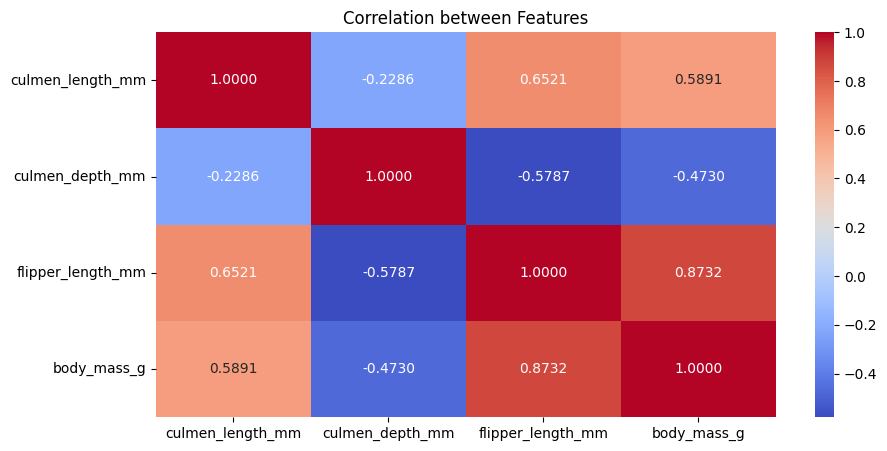

In [732]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Correlation between Features')
plt.show()

In [733]:
x = x.values.reshape(-1, 1)
x.shape

(334, 1)

In [734]:
regressor = LinearRegression()
regressor.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [735]:
previsoes = regressor.predict(x)
previsoes

array([3205.90613836, 3456.50625039, 3907.58645205, 3807.34640724,
       3656.98634002, 3205.90613836, 3907.58645205, 3256.02616077,
       3707.10636243, 4057.94651927, 3406.38622799, 3907.58645205,
       4007.82649686, 3356.26620558, 3857.46642965, 2855.06598151,
       3155.78611595, 3606.86631761, 3406.38622799, 3155.78611595,
       3506.6262728 , 3306.14618317, 3506.6262728 , 2754.8259367 ,
       3155.78611595, 3055.54607114, 3055.54607114, 3556.74629521,
       3356.26620558, 3907.58645205, 3957.70647446, 3656.98634002,
       3155.78611595, 3205.90613836, 3356.26620558, 3256.02616077,
       3907.58645205, 3456.50625039, 3957.70647446, 3406.38622799,
       3656.98634002, 3256.02616077, 3656.98634002, 3707.10636243,
       3456.50625039, 3556.74629521, 3656.98634002, 4158.18656408,
       3506.6262728 , 3707.10636243, 3456.50625039, 3807.34640724,
       3205.90613836, 3857.46642965, 3406.38622799, 3907.58645205,
       3406.38622799, 3757.22638483, 3356.26620558, 3757.22638

In [736]:
grafico = px.scatter(x = x.ravel(), y = y)
grafico.add_scatter(x = x.ravel(), y = previsoes, name = 'Regressão')
grafico.show()
plt.show()

In [737]:
previsao = regressor.predict([[230]])
print(f"Previsão: {previsao[0]:.2f}")

Previsão: 5661.79


<Axes: >

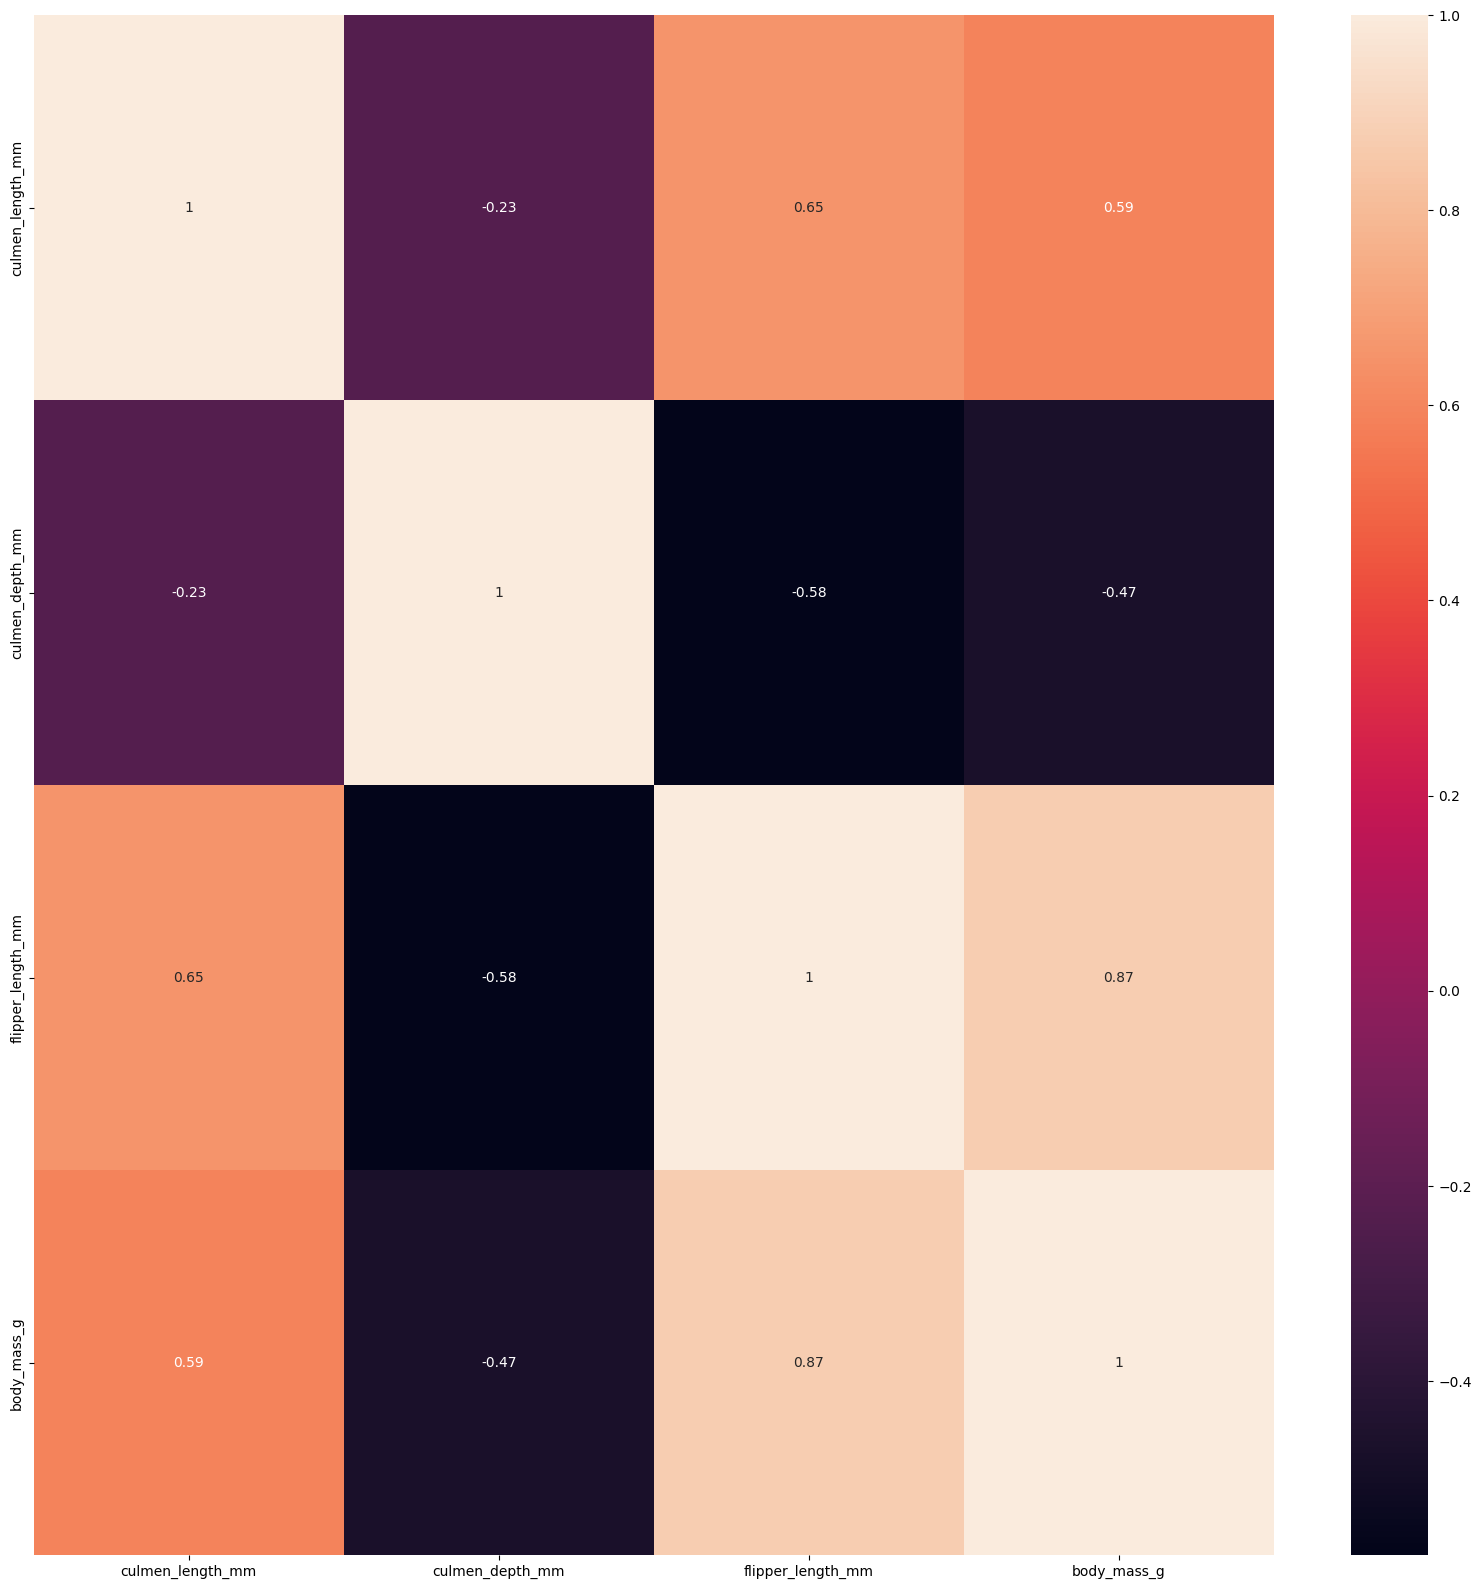

In [738]:
figura = plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True)

In [739]:
X = df[['flipper_length_mm',
        'culmen_length_mm']]
y = df['body_mass_g']

from sklearn.model_selection import train_test_split

x_treinamento, x_teste, y_treinamento, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

x_treinamento.shape, x_teste.shape

((267, 1), (67, 1))

In [740]:
regressor = LinearRegression()
regressor.fit(x_treinamento, y_treinamento)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [741]:
regressor.score(x_treinamento, y_treinamento)

0.760412651762199

In [742]:
regressor.score(x_teste, y_teste)

0.7703835587696063

In [743]:
previsoes = regressor.predict(x_teste)
previsoes

array([3051.64546665, 5272.21391923, 3909.59236879, 4060.99476328,
       3758.18997429, 4767.53927092, 5322.68138406, 3909.59236879,
       3808.65743912, 4212.39715777, 3960.05983362, 4060.99476328,
       4616.13687642, 3808.65743912, 4666.60434125, 3404.91772047,
       3505.85265014, 3758.18997429, 3505.85265014, 4868.47420058,
       3960.05983362, 3657.25504463, 4918.94166541, 4313.33208744,
       3203.04786115, 3556.32011497, 4818.00673575, 5675.95363788,
       3203.04786115, 4818.00673575, 3505.85265014, 5675.95363788,
       4060.99476328, 4262.8646226 , 5675.95363788, 4616.13687642,
       3909.59236879, 4565.66941159, 3657.25504463, 3455.3851853 ,
       3203.04786115, 3657.25504463, 4161.92969294, 4111.46222811,
       3606.7875798 , 3505.85265014, 5221.7464544 , 3556.32011497,
       3657.25504463, 5120.81152474, 3758.18997429, 5019.87659507,
       4717.07180609, 3152.58039632, 3707.72250946, 5171.27898957,
       3253.51532598, 3909.59236879, 3960.05983362, 4313.33208

In [744]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_teste, previsoes)
print(mae)

300.11665704207206


In [745]:
mse = mean_squared_error(y_teste, previsoes)
print(mse)

rmse = np.sqrt(mean_squared_error(y_teste, previsoes))
print(rmse)

140258.35657736714
374.5108230443643


In [746]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)

x_treinamento_poly = poly.fit_transform(x_treinamento)
x_teste_poly = poly.transform(x_teste)

regressor_poly = LinearRegression()
regressor_poly.fit(x_treinamento_poly, y_treinamento)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [747]:
print(regressor_poly.score(x_treinamento_poly, y_treinamento))
print(regressor_poly.score(x_teste_poly, y_teste))

0.7812297488600487
0.7629587547098376


In [748]:
previsoes_poly = regressor_poly.predict(x_teste_poly)
previsoes

array([3051.64546665, 5272.21391923, 3909.59236879, 4060.99476328,
       3758.18997429, 4767.53927092, 5322.68138406, 3909.59236879,
       3808.65743912, 4212.39715777, 3960.05983362, 4060.99476328,
       4616.13687642, 3808.65743912, 4666.60434125, 3404.91772047,
       3505.85265014, 3758.18997429, 3505.85265014, 4868.47420058,
       3960.05983362, 3657.25504463, 4918.94166541, 4313.33208744,
       3203.04786115, 3556.32011497, 4818.00673575, 5675.95363788,
       3203.04786115, 4818.00673575, 3505.85265014, 5675.95363788,
       4060.99476328, 4262.8646226 , 5675.95363788, 4616.13687642,
       3909.59236879, 4565.66941159, 3657.25504463, 3455.3851853 ,
       3203.04786115, 3657.25504463, 4161.92969294, 4111.46222811,
       3606.7875798 , 3505.85265014, 5221.7464544 , 3556.32011497,
       3657.25504463, 5120.81152474, 3758.18997429, 5019.87659507,
       4717.07180609, 3152.58039632, 3707.72250946, 5171.27898957,
       3253.51532598, 3909.59236879, 3960.05983362, 4313.33208

In [749]:
mean_absolute_error(y_teste, previsoes_poly)

307.15312134591767

In [750]:
rmse = np.sqrt(mean_squared_error(y_teste, previsoes_poly))
print(rmse)

380.5176817076979


In [751]:
from sklearn.tree import DecisionTreeRegressor
regressor_arvore = DecisionTreeRegressor()
regressor_arvore.fit(x_treinamento, y_treinamento)

print(regressor_arvore.score(x_treinamento, y_treinamento))
print(regressor_arvore.score(x_teste, y_teste))

0.8241179811171864
0.7413983887037772


In [752]:
previsoes_arvore = regressor_arvore.predict(x_teste)
previsoes_arvore

array([3350.        , 5580.        , 3841.66666667, 3750.        ,
       3437.5       , 4745.83333333, 5950.        , 3841.66666667,
       3617.5       , 4170.        , 3882.14285714, 3750.        ,
       4633.33333333, 3617.5       , 4345.83333333, 3518.75      ,
       3383.33333333, 3437.5       , 3383.33333333, 4768.75      ,
       3882.14285714, 3747.05882353, 5111.36363636, 4466.66666667,
       3343.75      , 3493.75      , 5150.        , 5850.        ,
       3343.75      , 5150.        , 3383.33333333, 5850.        ,
       3750.        , 3691.66666667, 5850.        , 4633.33333333,
       3841.66666667, 4503.57142857, 3747.05882353, 3680.        ,
       3343.75      , 3747.05882353, 3941.66666667, 3865.        ,
       3575.        , 3383.33333333, 5462.5       , 3493.75      ,
       3747.05882353, 5162.5       , 3437.5       , 4850.        ,
       4500.        , 3766.66666667, 3595.83333333, 5341.66666667,
       3287.5       , 3841.66666667, 3882.14285714, 4466.66666

In [753]:
mean_absolute_error(y_teste, previsoes_arvore)

316.397714445344

In [754]:
rmse = np.sqrt(mean_squared_error(y_teste, previsoes_arvore))
print(rmse)

397.44633396697014


In [755]:
from sklearn.ensemble import RandomForestRegressor
regressor_floresta = RandomForestRegressor(n_estimators=100)
regressor_floresta.fit(x_treinamento, y_treinamento)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [756]:
print(regressor_floresta.score(x_treinamento, y_treinamento))
print(regressor_floresta.score(x_teste, y_teste))

0.8233509093126804
0.7415644393038413


In [757]:
previsoes_floresta = regressor_floresta.predict(x_teste)
previsoes_floresta

array([3338.22261905, 5586.8205267 , 3841.37449395, 3741.41835317,
       3436.82718254, 4744.41995435, 5831.1248557 , 3841.37449395,
       3629.27599733, 4190.95793651, 3869.60163448, 3741.41835317,
       4633.85595238, 3629.27599733, 4329.660611  , 3526.07060856,
       3369.8912532 , 3436.82718254, 3369.8912532 , 4782.79275794,
       3869.60163448, 3765.56351439, 5109.22175879, 4412.9922619 ,
       3345.68896104, 3495.78883929, 5162.94394841, 5853.15124459,
       3345.68896104, 5162.94394841, 3369.8912532 , 5853.15124459,
       3741.41835317, 3741.90982143, 5853.15124459, 4633.85595238,
       3841.37449395, 4498.23270133, 3765.56351439, 3691.18869048,
       3345.68896104, 3765.56351439, 3937.02424242, 3870.04426684,
       3573.63019481, 3369.8912532 , 5475.2406746 , 3495.78883929,
       3765.56351439, 5133.89464286, 3436.82718254, 4858.52179834,
       4429.67312006, 3748.72857143, 3596.89765088, 5344.33894855,
       3316.52797619, 3841.37449395, 3869.60163448, 4412.99226

In [758]:
mean_absolute_error(y_teste, previsoes_floresta)

317.14246014702354

In [759]:
rmse = np.sqrt(mean_squared_error(y_teste, previsoes_floresta))
print(rmse)

397.31871140591846
